# Part 1: Analyse the Network

### Introduction to the network

The rock performers network is a directed graph of 484 mainstream rock artists constructed from Wikipedia, where edges represent hyperlinks between artist pages. In-degree reflects an artist's prominence (how often they are referenced), while out-degree reflects their page's comprehensiveness. We analyze this network using centrality measures, community detection, assortativity, and backbone extraction to understand the structure and key players within the rock music landscape.

### Basic Properties & Degree Analysis:

In [24]:
import networkx as nx
import requests
import matplotlib.pyplot as plt
import numpy as np
import re
import os
from collections import defaultdict
from io import BytesIO

# Download and load the network directly from GitHub like assignment 1.2
url = "https://raw.githubusercontent.com/Pakkutaq/SG_rock_network/main/rock_artists/rock_network.graphml"
response = requests.get(url)

G = nx.read_graphml(BytesIO(response.content))

We begin by examining the fundamental structural properties of the rock performers network. With 484 nodes and 7,267 edges, the network has a density of 0.0311, indicating a sparse network where only about 3% of all possible connections exist. The average clustering coefficient is 0.2338, suggesting moderate local clustering where artists who share connections tend to be connected to each other.

Network density: 0.0311
Average clustering coefficient: 0.2338


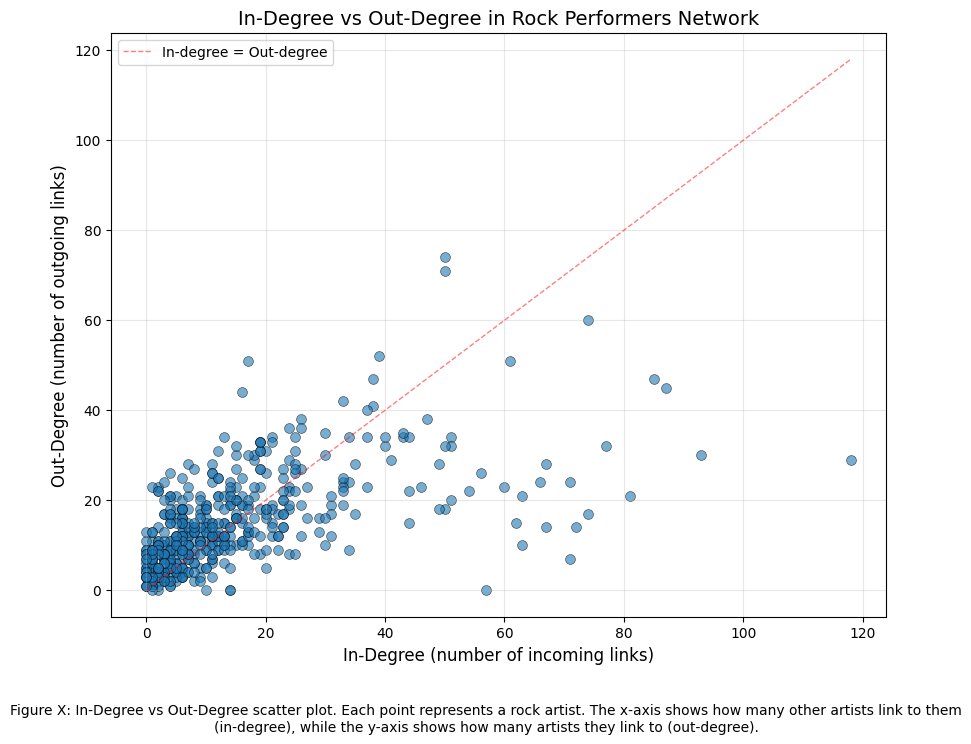


Correlation between in-degree and out-degree: 0.5831


In [16]:
# Calculate density
density = nx.density(G)
print(f"Network density: {density:.4f}")

# Calculate clustering coefficient
avg_clustering = nx.average_clustering(G.to_undirected())
print(f"Average clustering coefficient: {avg_clustering:.4f}")

# Get in-degrees and out-degrees for all nodes
in_degrees = [G.in_degree(node) for node in G.nodes()]
out_degrees = [G.out_degree(node) for node in G.nodes()]

# Create scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(in_degrees, out_degrees, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.xlabel('In-Degree (number of incoming links)', fontsize=12)
plt.ylabel('Out-Degree (number of outgoing links)', fontsize=12)
plt.title('In-Degree vs Out-Degree in Rock Performers Network', fontsize=14)
plt.grid(True, alpha=0.3)

# Add a reference line (y=x) to show where in-degree equals out-degree
max_degree = max(max(in_degrees), max(out_degrees))
plt.plot([0, max_degree], [0, max_degree], 'r--', alpha=0.5, linewidth=1, label='In-degree = Out-degree')
plt.legend()

plt.figtext(0.5, 0.01, "Figure X: In-Degree vs Out-Degree scatter plot. Each point represents a rock artist. " \
            "The x-axis shows how many other artists link to them (in-degree), while the y-axis shows how many artists they link to (out-degree).", 
            ha="center", fontsize=10, wrap=True)
plt.subplots_adjust(bottom=0.15)
plt.show()

# Calculate correlation between in-degree and out-degree
correlation = np.corrcoef(in_degrees, out_degrees)[0, 1]
print(f"\nCorrelation between in-degree and out-degree: {correlation:.4f}")

The scatter plot in Figure X shows the relationship between in-degree (how often artists are cited) and out-degree (how many artists they cite), with a correlation of 0.5831. Most artists cluster in the lower-left region with both low in-degree and out-degree. However, highly referenced artists (high in-degree) often have moderate out-degree, while some less famous artists have very high out-degree (60-74 links). This indicates that being frequently cited doesn't necessarily mean an artist's Wikipedia page extensively references others - fame and citation behavior are partially independent.

### Backbone analysis

The full network with 7,267 edges is too dense to easily identify the most important structural patterns. To reveal the core relationships between rock artists, we first create a weighted version of the network where edge weights are proportional to edge betweenness centrality - edges that lie on many shortest paths between artists receive higher weights. We normalize these weights so the minimum is 1 and the maximum is 100. We then extract a network backbone using the disparity filter with a significance level of α = 0.05, which identifies edges that carry disproportionately more weight in a node's connectivity pattern.


Backbone Statistics:
  Nodes: 391 (80.8% of original)
  Edges: 462 (7.7% of original)
  Density: 0.0061 (original: 0.0513)


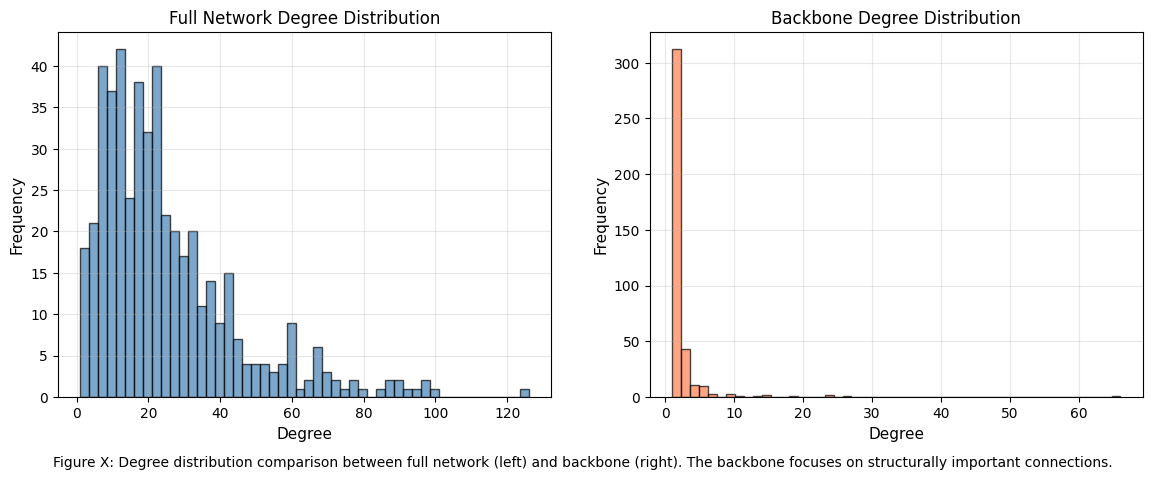

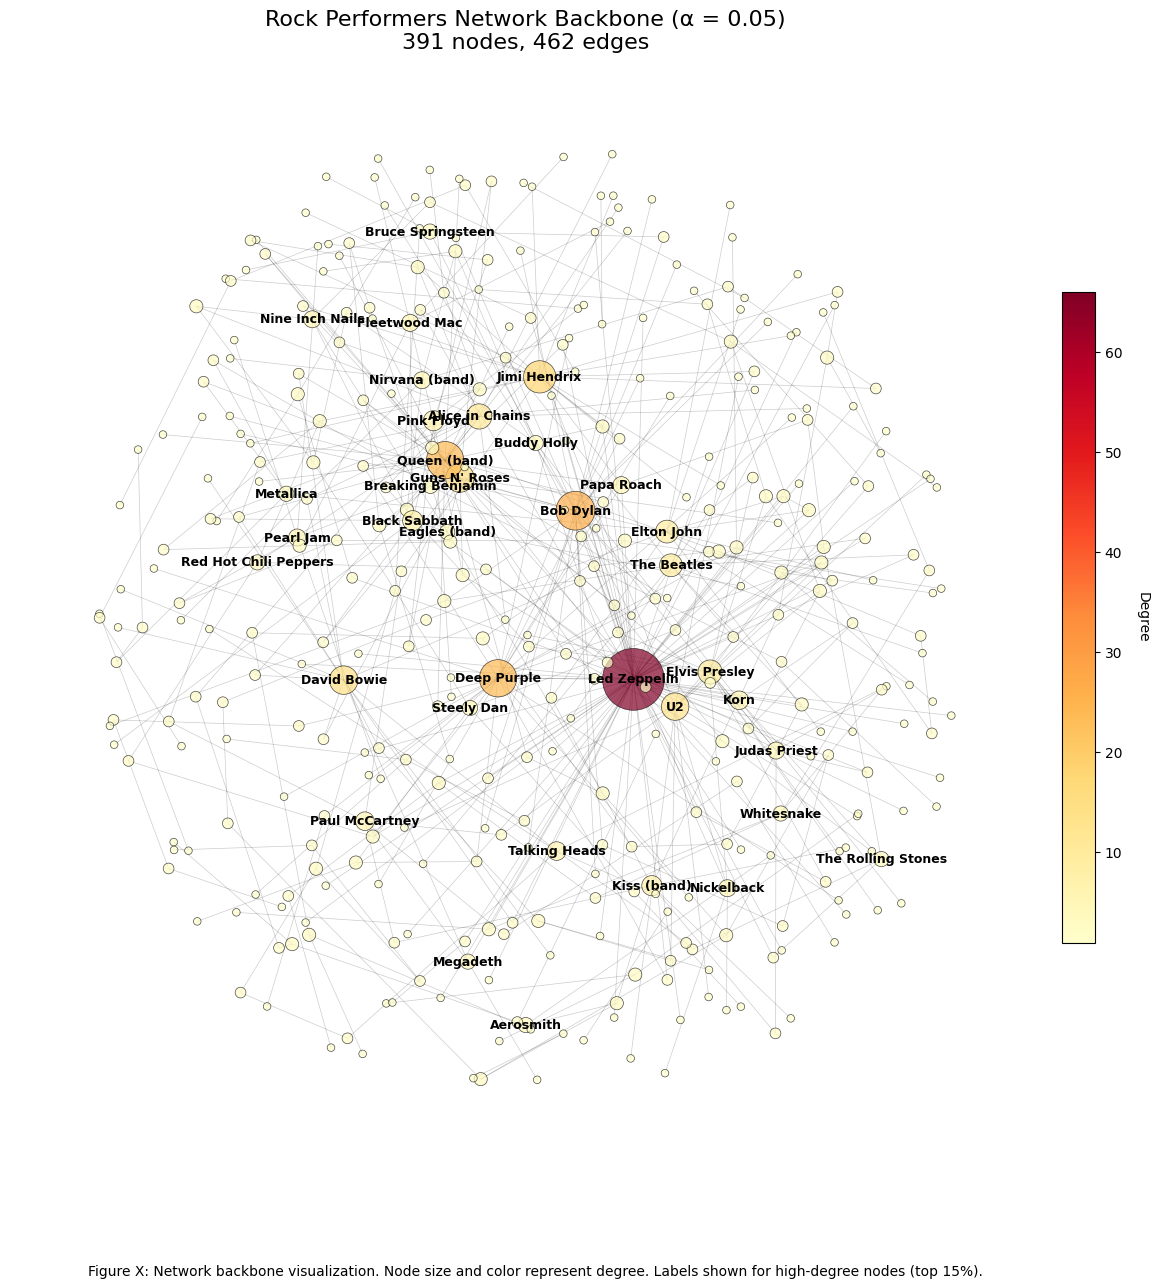

In [17]:
# Step 1: Convert to undirected (if not already)
G_undirected = G.to_undirected()

# Step 2: Calculate edge betweenness centrality
edge_betweenness = nx.edge_betweenness_centrality(G_undirected)

# Step 3: Normalize edge betweenness to range [1, 100]
min_betweenness = min(edge_betweenness.values())
max_betweenness = max(edge_betweenness.values())

# Create weighted network
G_weighted = G_undirected.copy()

for edge, betweenness in edge_betweenness.items():
    # Normalize to [1, 100]
    normalized_weight = 1 + 99 * (betweenness - min_betweenness) / (max_betweenness - min_betweenness)
    G_weighted[edge[0]][edge[1]]['weight'] = normalized_weight


# Step 4: Apply disparity filter
def disparity_filter(G, alpha=0.05):
    """
    Apply disparity filter to extract network backbone.
    
    For each node, the disparity filter tests whether each edge weight
    is significantly larger than expected under a null model.
    """
    B = nx.Graph()
    B.add_nodes_from(G.nodes(data=True))
    
    for node in G.nodes():
        edges = list(G.edges(node, data=True))
        
        if len(edges) == 0:
            continue
            
        k = len(edges)  # degree
        s = sum(d.get('weight', 1) for u, v, d in edges)  # total strength
        
        for u, v, data in edges:
            weight = data.get('weight', 1)
            
            if s > 0:
                # Disparity filter p-value
                p_value = (1 - weight / s) ** (k - 1)
                
                if p_value < alpha:
                    if not B.has_edge(u, v):
                        B.add_edge(u, v, weight=weight, p_value=p_value)
    
    return B

backbone = disparity_filter(G_weighted, alpha=0.135)

# Remove isolated nodes
isolated = [node for node in backbone.nodes() if backbone.degree(node) == 0]
backbone.remove_nodes_from(isolated)

# Step 5: Report statistics
print(f"\nBackbone Statistics:")
print(f"  Nodes: {backbone.number_of_nodes()} ({100*backbone.number_of_nodes()/G.number_of_nodes():.1f}% of original)")
print(f"  Edges: {backbone.number_of_edges()} ({100*backbone.number_of_edges()/G_undirected.number_of_edges():.1f}% of original)")
print(f"  Density: {nx.density(backbone):.4f} (original: {nx.density(G_undirected):.4f})")

# Step 6: Compare degree distributions
G_degrees = [d for n, d in G_undirected.degree()]
backbone_degrees = [d for n, d in backbone.degree()]

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Full network degree distribution
axs[0].hist(G_degrees, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axs[0].set_xlabel('Degree', fontsize=11)
axs[0].set_ylabel('Frequency', fontsize=11)
axs[0].set_title('Full Network Degree Distribution')
axs[0].grid(True, alpha=0.3)

# Backbone degree distribution
axs[1].hist(backbone_degrees, bins=50, edgecolor='black', alpha=0.7, color='coral')
axs[1].set_xlabel('Degree', fontsize=11)
axs[1].set_ylabel('Frequency', fontsize=11)
axs[1].set_title('Backbone Degree Distribution')
axs[1].grid(True, alpha=0.3)

plt.figtext(0.5, 0.01, "Figure X: Degree distribution comparison between full network (left) and backbone (right). " \
            "The backbone focuses on structurally important connections.",
            ha="center", fontsize=10, wrap=True)
plt.subplots_adjust(bottom=0.15)
plt.show()

# Step 7: Visualize the backbone
plt.figure(figsize=(14, 14))

pos = nx.spring_layout(backbone, k=1.0, iterations=50, seed=42)

# Node sizes and colors based on degree in backbone
node_sizes = [backbone.degree(node) * 30 for node in backbone.nodes()]
node_colors = [backbone.degree(node) for node in backbone.nodes()]

# Draw
nx.draw_networkx_nodes(backbone, pos, node_size=node_sizes, node_color=node_colors,
                       cmap=plt.cm.YlOrRd, alpha=0.7, edgecolors='black', linewidths=0.5)
nx.draw_networkx_edges(backbone, pos, alpha=0.2, width=0.5)

# Label high-degree nodes
high_degree_nodes = [node for node in backbone.nodes() 
                     if backbone.degree(node) > np.percentile(backbone_degrees, 85)]
labels = {node: node for node in high_degree_nodes}
nx.draw_networkx_labels(backbone, pos, labels, font_size=9, font_weight='bold')

plt.title(f'Rock Performers Network Backbone (α = 0.05)\n{backbone.number_of_nodes()} nodes, {backbone.number_of_edges()} edges',
          fontsize=16)
plt.axis('off')

sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd, 
                           norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Degree', rotation=270, labelpad=20)

plt.figtext(0.5, 0.01, "Figure X: Network backbone visualization. Node size and color represent degree. " \
            "Labels shown for high-degree nodes (top 15%).",
            ha="center", fontsize=10, wrap=True)
plt.subplots_adjust(bottom=0.08)
plt.show()

#TODO COMMENTS ON PLOTS AND BACKBONE STATISTICS

### Centrality Analysis and Assortativity

To identify the most important artists in the rock performers network, we calculate three centrality measures that capture different aspects of importance: degree centrality (number of connections), betweenness centrality (extent to which an artist lies on paths between others), and closeness centrality (average distance to all other artists).
The top artists by each measure reveal different roles within the network. Led Zeppelin dominates all three measures, ranking first in degree (0.2609), betweenness (0.0462), and closeness centrality, establishing them as the most central artist overall. Queen and Bob Dylan also rank highly across all measures (both in top 3), indicating their dual role as both highly connected hubs and critical bridges. However, interesting differences emerge: Metallica ranks 4th in degree centrality but drops to 10th in betweenness, suggesting they are well-connected but not essential for bridging different parts of the network. Conversely, Deep Purple ranks 5th in degree but 4th in betweenness and closeness, indicating they serve as an important bridge despite having fewer connections than some peers.

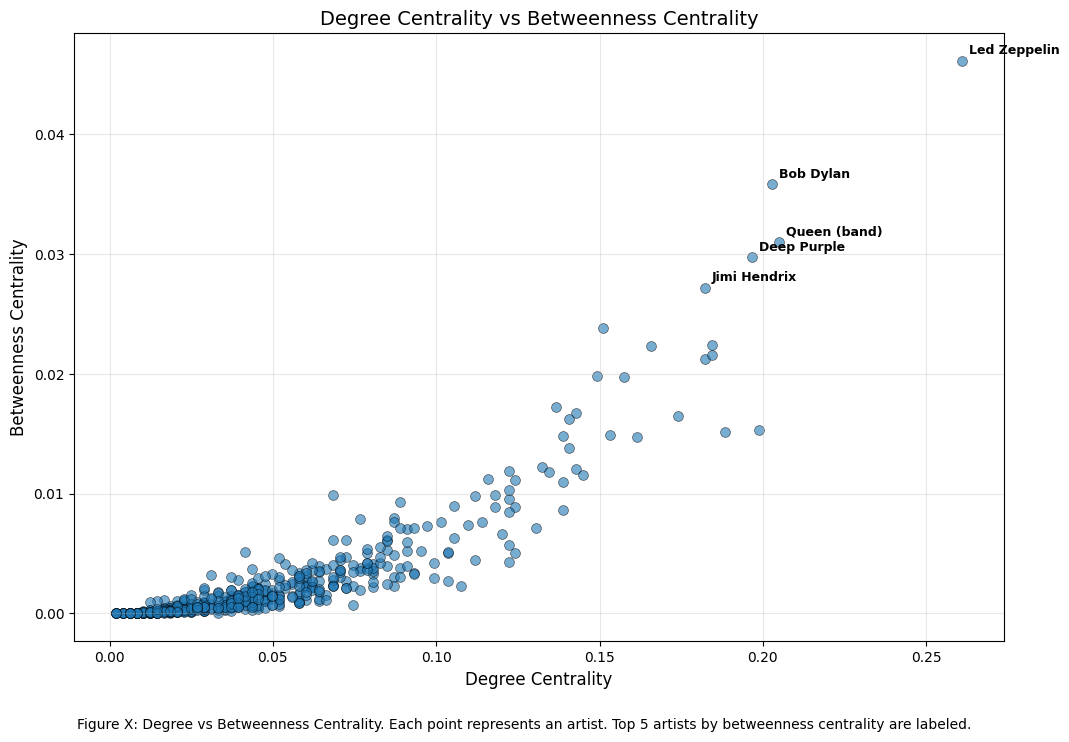


Correlation between degree and betweenness centrality: 0.8832

Degree Assortativity Coefficient: 0.0086

Interpretation: Near-zero assortativity suggests no strong preference for similar-degree connections,
indicating a relatively egalitarian network structure.


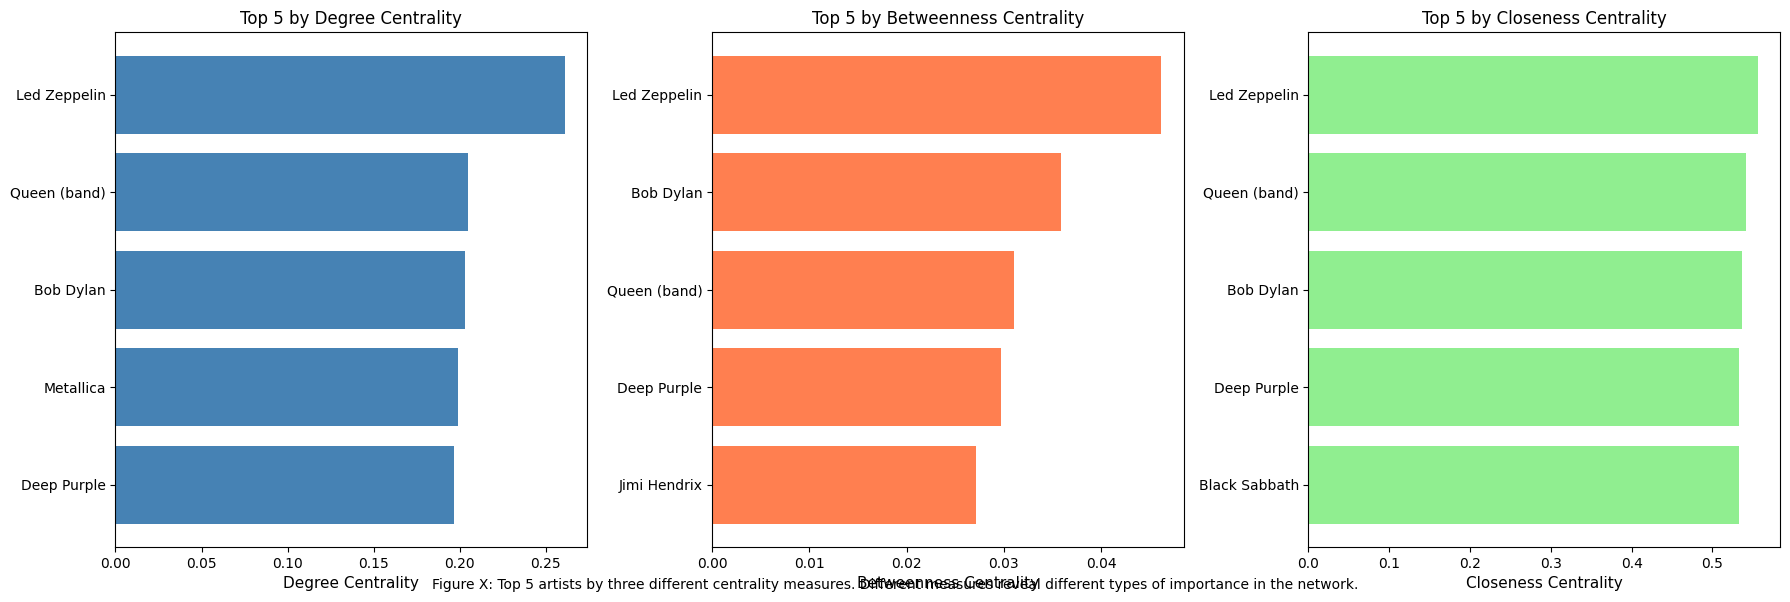

In [ ]:
# Work with undirected version for centrality analysis
G_undirected = G.to_undirected()

# Calculate three centrality measures
degree_centrality = nx.degree_centrality(G_undirected)
betweenness_centrality = nx.betweenness_centrality(G_undirected)
closeness_centrality = nx.closeness_centrality(G_undirected)

# Get top 10 artists for each centrality measure
top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
top_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
top_closeness = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

# Visualize: Scatter plot of Degree vs Betweenness Centrality
fig, ax = plt.subplots(figsize=(12, 8))

degree_values = list(degree_centrality.values())
betweenness_values = list(betweenness_centrality.values())
artists = list(degree_centrality.keys())

ax.scatter(degree_values, betweenness_values, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax.set_xlabel('Degree Centrality', fontsize=12)
ax.set_ylabel('Betweenness Centrality', fontsize=12)
ax.set_title('Degree Centrality vs Betweenness Centrality', fontsize=14)
ax.grid(True, alpha=0.3)

# Label the top artists (top 5 by betweenness)
top_5_betweenness_artists = [artist for artist, _ in top_betweenness[:5]]
for artist in top_5_betweenness_artists:
    idx = artists.index(artist)
    ax.annotate(artist, 
                (degree_values[idx], betweenness_values[idx]),
                fontsize=9,
                fontweight='bold',
                xytext=(5, 5),
                textcoords='offset points')

plt.figtext(0.5, 0.01, "Figure X: Degree vs Betweenness Centrality. Each point represents an artist. " \
            "Top 5 artists by betweenness centrality are labeled.",
            ha="center", fontsize=10, wrap=True)
plt.subplots_adjust(bottom=0.12)
plt.show()

# Calculate correlation between centralities
corr_deg_bet = np.corrcoef(degree_values, betweenness_values)[0, 1]
print(f"\nCorrelation between degree and betweenness centrality: {corr_deg_bet:.4f}")

# Calculate degree assortativity
assortativity = nx.degree_assortativity_coefficient(G_undirected)
print(f"\n" + "="*70)
print(f"Degree Assortativity Coefficient: {assortativity:.4f}")
print("="*70)

# Optional: Create bar chart comparing top 5 across all three measures
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Degree centrality bar chart
top_5_degree = top_degree[:5]
artists_deg = [artist for artist, _ in top_5_degree]
values_deg = [val for _, val in top_5_degree]
axs[0].barh(artists_deg, values_deg, color='steelblue')
axs[0].set_xlabel('Degree Centrality', fontsize=11)
axs[0].set_title('Top 5 by Degree Centrality', fontsize=12)
axs[0].invert_yaxis()

# Betweenness centrality bar chart
top_5_bet = top_betweenness[:5]
artists_bet = [artist for artist, _ in top_5_bet]
values_bet = [val for _, val in top_5_bet]
axs[1].barh(artists_bet, values_bet, color='coral')
axs[1].set_xlabel('Betweenness Centrality', fontsize=11)
axs[1].set_title('Top 5 by Betweenness Centrality', fontsize=12)
axs[1].invert_yaxis()

# Closeness centrality bar chart
top_5_close = top_closeness[:5]
artists_close = [artist for artist, _ in top_5_close]
values_close = [val for _, val in top_5_close]
axs[2].barh(artists_close, values_close, color='lightgreen')
axs[2].set_xlabel('Closeness Centrality', fontsize=11)
axs[2].set_title('Top 5 by Closeness Centrality', fontsize=12)
axs[2].invert_yaxis()

plt.figtext(0.5, 0.01, "Figure X: Top 5 artists by three different centrality measures. " \
            "Different measures reveal different types of importance in the network.",
            ha="center", fontsize=10, wrap=True)
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()

Figure X shows a scatter plot comparing degree and betweenness centrality, revealing a strong positive correlation (r = 0.8832). This indicates that highly connected artists typically also serve as bridges between other artists. However, the relationship is not perfectly linear - Led Zeppelin and Bob Dylan have disproportionately high betweenness relative to their degree, suggesting they occupy particularly strategic positions connecting different musical communities.

Finally, we examine the network's degree assortativity coefficient of 0.0086, indicating near-zero assortativity. This suggests no strong preference for high-degree nodes to connect with other high-degree nodes or with low-degree nodes. The network exhibits a relatively egalitarian structure where well-connected artists are equally likely to link to both other hubs and peripheral artists, rather than forming an exclusive "rich club" of interconnected superstars.

Near-zero assortativity suggests no strong preference for similar-degree connections,
indicating a relatively egalitarian network structure.

### Final remarks on the rock performeres network



# Part 2: Genres and communities and plotting


In network analysis, modularity measures how well a network can be divided into distinct communities. A network has high modularity when nodes within communities are densely connected to each other, but sparsely connected to nodes in other communities.

In the context of music networks, genres represent natural communities. Artists within the same genre tend to reference and influence each other more frequently than artists from different genres. For example, heavy metal bands are more likely to link to other metal bands on their Wikipedia pages than to pop artists. By applying community detection algorithms to our rock artists network, we can discover these genre-based communities and use modularity to quantify how well they align with actual genre boundaries.

In [109]:
def extract_infobox(wikitext):
    """
    Extract the infobox from Wikipedia wikitext.
    Returns the infobox text or None if not found.
    """
    # Find {{Infobox ... }}
    start = wikitext.find('{{Infobox')
    if start == -1:
        return None
    
    # Count braces to find the matching closing }}
    brace_count = 0
    i = start
    while i < len(wikitext):
        if wikitext[i:i+2] == '{{':
            brace_count += 1
            i += 2
        elif wikitext[i:i+2] == '}}':
            brace_count -= 1
            if brace_count == 0:
                return wikitext[start:i+2]
            i += 2
        else:
            i += 1
    
    return None

def extract_genre_field(infobox):
    """
    Extract the genre field from an infobox.
    Returns the raw genre text or None if not found.
    """
    if not infobox:
        return None
    
    # Look for | genre = or | genres =
    # Capture everything until we hit another | field that starts a line
    pattern = r'\|\s*genres?\s*=\s*(.+?)(?=\n\|[a-zA-Z]|\n\}\})'
    match = re.search(pattern, infobox, re.IGNORECASE | re.DOTALL)
    
    if match:
        result = match.group(1).strip()
        # If it ends with incomplete template, try to complete it
        # Count opening {{ and closing }}
        open_braces = result.count('{{')
        close_braces = result.count('}}')
        if open_braces > close_braces:
            # Add missing closing braces
            result += '}}'
        return result
    return None

def clean_wiki_markup(text):
    """
    Remove wiki markup from text to get clean genre names.
    """
    if not text:
        return text
    
    # Remove {{...}} templates
    text = re.sub(r'\{\{[^}]*\}\}', '', text)
    
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    
    # Extract text from wiki links [[Link]] or [[Link|Display]]
    text = re.sub(r'\[\[([^\]|]+\|)?([^\]]+)\]\]', r'\2', text)
    
    # Remove references
    text = re.sub(r'<ref[^>]*>.*?</ref>', '', text, flags=re.DOTALL)
    
    # Remove remaining brackets
    text = re.sub(r'[\[\]{}]', '', text)
    
    return text.strip()

def parse_genres(genre_text):
    """
    Parse the genre text and return a list of cleaned genre names.
    """
    if not genre_text:
        return []
    
    # First extract content from flatlist/hlist/plainlist/unbulleted list templates
    template_pattern = r'\{\{(?:flatlist|hlist|plainlist|unbulleted list)\s*\|(.+?)\}\}'
    match = re.search(template_pattern, genre_text, re.IGNORECASE | re.DOTALL)
    if match:
        genre_text = match.group(1)  # Extract content inside template
    
    # Clean wiki markup
    genre_text = clean_wiki_markup(genre_text)
    
    # Replace various delimiters with commas
    genre_text = re.sub(r'[•\n*]', ',', genre_text)
    genre_text = re.sub(r'\s*,\s*', ',', genre_text)
    
    # Split by comma
    genres = [g.strip() for g in genre_text.split(',') if g.strip()]
    
    # Clean and normalize each genre
    cleaned_genres = []
    for genre in genres:
        # Convert to lowercase
        genre = genre.lower()
        
        # Remove parenthetical notes
        genre = re.sub(r'\([^)]*\)', '', genre)
        
        # Simplify common variations
        replacements = {
            "rock'n'roll": "rock and roll",
            "rock 'n' roll": "rock and roll", 
            "rock & roll": "rock and roll",
            "rock n roll": "rock and roll",
            "r&b": "rhythm and blues",
            "rnb": "rhythm and blues",
        }
        
        for old, new in replacements.items():
            if old in genre:
                genre = genre.replace(old, new)
        
        # Remove extra whitespace
        genre = ' '.join(genre.split())
        
        # Skip empty, very short genres, or template artifacts
        if len(genre) <= 2:
            continue
        if genre in ['flatlist', 'hlist', 'plainlist', 'nowrap', 'unbulleted list', 'flat list']:
            continue
            
        cleaned_genres.append(genre)
    
    return cleaned_genres

def get_artist_genres(pages_dir='rock_artists/pages'):
    """
    Extract genres for all artists and return a dictionary.
    
    Returns:
        dict: Dictionary mapping artist names to lists of genres
              Example: {'The Beatles': ['rock', 'pop'], 'AC/DC': ['hard rock', 'rock']}
    """
    import re
    
    # Load performer list to get correct names
    with open('rock_artists/PERFORMER_LIST.txt', 'r', encoding='utf-8') as f:
        performers = [line.strip() for line in f if line.strip()]
    
    # Create same sanitize function and mapping as network building
    def sanitize_filename(filename):
        filename = re.sub(r'\s*\([^)]*\)\s*', '', filename)
        replacements = {
            '/': '_', '\\': '_', ':': '_', '*': '_', '?': '_',
            '"': '_', '<': '_', '>': '_', '|': '_', '!': '', '.': '_'
        }
        for old, new in replacements.items():
            filename = filename.replace(old, new)
        filename = re.sub(r'_+', '_', filename)
        return filename.strip('_')
    
    filename_to_performer = {}
    for performer in performers:
        sanitized = sanitize_filename(performer.replace(' ', '_'))
        filename_to_performer[sanitized] = performer
    
    artist_genres = {}
    
    # Get all text files
    files = [f for f in os.listdir(pages_dir) if f.endswith('.txt')]
    
    for filename in files:
        # Get artist name using same mapping as network ng
        base_filename = filename[:-4]  # Remove .txt
        artist_name = filename_to_performer.get(base_filename, base_filename.replace('_', ' '))
        
        # Read the page
        filepath = os.path.join(pages_dir, filename)
        with open(filepath, 'r', encoding='utf-8') as f:
            content = f.read()
        
        # Extract infobox
        infobox = extract_infobox(content)
        if not infobox:
            continue
        
        # Extract genre field
        genre_field = extract_genre_field(infobox)
        if not genre_field:
            continue
        
        # Parse and clean genres
        genres = parse_genres(genre_field)
        
        if genres:
            artist_genres[artist_name] = genres
    
    print(f"Extracted genres for {len(artist_genres)} artists")
    return artist_genres

In [110]:
artist_genres = get_artist_genres()

def create_genre_partition(G, artist_genres):
    """
    Create a partition where each node is assigned to its FIRST genre.
    
    Returns:
        - G_undirected: undirected network with only nodes that have genres
        - partition: dict mapping node -> community (genre)
        - genre_to_nodes: dict mapping genre -> list of nodes
    """
    # Convert to undirected
    G_undirected = G.to_undirected()
    
    # Keep only nodes with genre information
    nodes_with_genres = [node for node in G_undirected.nodes() if node in artist_genres]
    G_undirected = G_undirected.subgraph(nodes_with_genres).copy()
        
    # Assign each node to its first genre
    partition = {}
    genre_to_nodes = defaultdict(list)
    
    for node in G_undirected.nodes():
        if node in artist_genres and len(artist_genres[node]) > 0:
            first_genre = artist_genres[node][0]
            partition[node] = first_genre
            genre_to_nodes[first_genre].append(node)
    
    
    return G_undirected, partition, genre_to_nodes


def calculate_modularity(G, partition):
    """
    Calculate modularity M using NetworkX's built-in function.
    This implements equation 9.12 from Network Science book.
    
    M = (1/2m) * sum over all edges (A_ij - k_i*k_j/2m) * delta(c_i, c_j)
    
    where:
    - A_ij = 1 if there's an edge between i and j
    - k_i, k_j are degrees of nodes i and j
    - m is total number of edges
    - delta(c_i, c_j) = 1 if nodes i and j are in same community
    """
    # Create list of communities (sets of nodes)
    communities = defaultdict(set)
    for node, community in partition.items():
        communities[community].add(node)
    
    community_list = list(communities.values())
    
    # Calculate modularity
    modularity = nx.community.modularity(G, community_list)
    
    return modularity

#Manually override one of the genres, because i dont know why it's the only one that messes up.
artist_genres["Paul McCartney and Wings"] = ["soft rock"]
G_undirected, partition, genre_to_nodes = create_genre_partition(G, artist_genres)

Extracted genres for 471 artists


In [111]:
modularity = calculate_modularity(G_undirected, partition)

def print_genre_communities(genre_to_nodes, modularity):
    """Print genre-based communities and modularity."""
    
    print("\n" + "="*60)
    print("GENRE-BASED COMMUNITIES")
    print("="*60)
    
    sorted_genres = sorted(genre_to_nodes.items(), key=lambda x: len(x[1]), reverse=True)
    
    print(f"\nTotal genres: {len(sorted_genres)}")
    print(f"Modularity (M): {modularity:.4f}\n")
    
    print(f"{'Genre':<30} {'Artists':<10}")
    print("-" * 60)
    
    for genre, nodes in sorted_genres[:15]:
        print(f"{genre:<30} {len(nodes):<10}")
    
    # Stats
    sizes = [len(nodes) for nodes in genre_to_nodes.values()]
    print(f"\nLargest community: {max(sizes)} artists")
    print(f"Smallest community: {min(sizes)} artists")
    print(f"Average: {np.mean(sizes):.1f} artists")

print_genre_communities(genre_to_nodes, modularity)


GENRE-BASED COMMUNITIES

Total genres: 274
Modularity (M): 0.0348

Genre                          Artists   
------------------------------------------------------------
alternative rock               43        
rock                           30        
hard rock                      28        
heavy metal                    11        
pop rock                       11        
post-grunge                    10        
alternative metal              9         
progressive rock               8         
indie rock                     8         
punk rock                      7         
new wave                       7         
pop-punk                       7         
groove metal                   5         
rock and roll                  5         
nu metal                       3         

Largest community: 43 artists
Smallest community: 1 artists
Average: 1.7 artists


We partitioned the network into genre-based communities, where each artist is assigned to their first listed genre from Wikipedia. This resulted in 274 distinct genre communities from 471 artists. A limitation by genre-based communities could also come from the fact that many artists have more than 1 genre, and here we just picked the first one listed. This means there may, in fact, be larger communities. On the other hand, this could mean there are no communities, if all artists have the genre "rock".

We discuss modularity further in the assignment.

### The matrix D and structural communities

In [98]:
def detect_structural_communities(G):
    """
    Detect communities using Louvain algorithm (greedy modularity optimization).
    
    Returns:
        - communities: list of sets (each set is a community)
        - partition: dict mapping node -> community_id
        - modularity: modularity of this partition
    """
    # Use Louvain algorithm
    communities = nx.community.louvain_communities(G, seed=42)
    
    # Convert to partition dict
    partition = {}
    for community_id, community in enumerate(communities):
        for node in community:
            partition[node] = community_id
    
    # Calculate modularity
    modularity = nx.community.modularity(G, communities)
    
    return communities, partition, modularity

def print_structural_communities(communities, partition):
    """Print structural communities nicely."""
    print("\n" + "="*70)
    print("STRUCTURAL COMMUNITIES (Louvain Algorithm)")
    print("="*70)
    
    # Sort by size
    sorted_communities = sorted(enumerate(communities), key=lambda x: len(x[1]), reverse=True)
    
    print(f"\nTotal communities detected: {len(communities)}")
    print(f"Total nodes assigned: {len(partition)}")
    
    print("\nTop 15 communities by size:")
    print(f"{'Rank':<6} {'Community ID':<15} {'Size':<8} {'% of Network':<12}")
    print("-" * 70)
    
    total_nodes = len(partition)
    for i, (comm_id, comm_nodes) in enumerate(sorted_communities[:15], 1):
        percentage = (len(comm_nodes) / total_nodes) * 100
        print(f"{i:<6} {comm_id:<15} {len(comm_nodes):<8} {percentage:>6.1f}%")
    
    # Show size distribution
    sizes = [len(c) for c in communities]
    print(f"\nCommunity size statistics:")
    print(f"  Largest:  {max(sizes)} nodes")
    print(f"  Smallest: {min(sizes)} nodes")
    print(f"  Mean:     {np.mean(sizes):.1f} nodes")
    print(f"  Median:   {np.median(sizes):.1f} nodes")


communities, partition, modularity = detect_structural_communities(G)
print(f"Modularity for structural communities {modularity}")
print_structural_communities(communities, partition)



Modularity for structural communities 0.36246235013692385

STRUCTURAL COMMUNITIES (Louvain Algorithm)

Total communities detected: 5
Total nodes assigned: 484

Top 15 communities by size:
Rank   Community ID    Size     % of Network
----------------------------------------------------------------------
1      1               188        38.8%
2      3               149        30.8%
3      0               97         20.0%
4      2               47          9.7%
5      4               3           0.6%

Community size statistics:
  Largest:  188 nodes
  Smallest: 3 nodes
  Mean:     96.8 nodes
  Median:   97.0 nodes


#### Modularity Analysis:
The genre-based partition yields a modularity of M = 0.0348, which is very low. Modularity values above 0.3 typically indicate strong community structure, while values below 0.1 suggest weak or no meaningful community divisions.

The structural-based partition yields a modularity of 0.36. Modularity measures how well a network divides into communities - values above 0.3 indicate strong community structure.
This high modularity indicates that genres form distinct communities in the network. Artists predominantly link to others within their genre, validating genres as meaningful organizational categories.

We notice a big difference between genre-based partition and strucural-based partition, which can be further analyzed in the confusion matrix:

In [104]:
import pandas as pd
from collections import defaultdict
# Get top 5 genres and top 5 communities
sorted_genres = sorted(genre_to_nodes.items(), key=lambda x: len(x[1]), reverse=True)
top_genres = [g for g, _ in sorted_genres[:4]]

sorted_comms = sorted(communities, key=lambda c: len(c), reverse=True)
top_communities = list(range(len(sorted_comms[:4])))  # [0,1,2,3,4]

# Initialize D
D = pd.DataFrame(
    0,
    index=top_genres,
    columns=[f"Community {i}" for i in top_communities]
)

# Fill D(i, j)
for genre in top_genres:
    genre_nodes = set(genre_to_nodes[genre])
    for j in top_communities:
        comm_nodes = sorted_comms[j]
        # count intersection of nodes
        D.loc[genre, f"Community {j}"] = len(genre_nodes.intersection(comm_nodes))

D


,Community 0,Community 1,Community 2,Community 3
alternative rock,1,30,1,11
rock,22,3,4,1
hard rock,2,1,19,6
heavy metal,0,0,10,1


By analysing the matrix we see that community 2 has the majority in hard/heavy metal which makes sense as these genres share a lot in music. We also notice that community 1 has it's majority in alternative rock which also makes sense, just by reading the name. Then we see community 0 which is more pop-rock orientated. Lastly community 3 appears to not be a huge part of the top 4 genres.

#### Plotting the communities